# Can Molecular Dipole Moments Predict Molecular Potential Energy?

### A Machine Learning Exploration Using the CHAMPS Dataset
---

## Dataset Description
(Kaggle link : https://www.kaggle.com/competitions/champs-scalar-coupling/)

This study utilizes data derived from the **CHAMPS Scalar Coupling** dataset, originally released as part of the Kaggle competition *"Predicting Molecular Properties"* and distributed under the MIT License.

The dataset consists of quantum-chemically computed properties for a large collection of small organic molecules containing carbon, hydrogen, nitrogen, oxygen, and fluorine atoms. Molecular geometries and electronic properties were obtained using density functional theory (DFT) calculations, providing a rich source of physicochemical descriptors suitable for molecular machine learning applications.

For the present analysis, two subsets of the dataset are employed:

### Dipole Moments Dataset

The file `dipole_moments.csv` contains the Cartesian components of the molecular dipole moment vector for each molecule.

| Variable | Description |
|-----------|-------------|
| `molecule_name` | Unique molecular identifier |
| `X` | x-component of the dipole moment |
| `Y` | y-component of the dipole moment |
| `Z` | z-component of the dipole moment |

The dipole moment describes the separation of positive and negative charge within a molecule and serves as a measure of molecular polarity.

### Potential Energy Dataset

The file `potential_energy.csv` contains the calculated molecular potential energy associated with each molecule.

| Variable | Description |
|-----------|-------------|
| `molecule_name` | Unique molecular identifier |
| `potential_energy` | Quantum-chemically calculated molecular potential energy |

Potential energy reflects the energetic state and stability of a molecular configuration and is influenced by electronic structure and intermolecular interactions.

### Data Integration

Both datasets are linked through the common key `molecule_name`. A one-to-one merge is performed to associate dipole moment components with their corresponding molecular potential energies, yielding the final dataset used in this study.

### Citation and License

Source: **CHAMPS Scalar Coupling – Predicting Molecular Properties**, Kaggle Competition.

License: **MIT License**

This work makes use of publicly available data, and all credit for dataset generation belongs to the original competition organizers and contributors.

---

## Introduction

Understanding the relationship between molecular properties and energy is a fundamental problem in chemistry.

Potential energy plays a crucial role in determining molecular stability and reactivity, while dipole moments describe the distribution of charge within a molecule. Since electrostatic interactions contribute significantly to molecular energy, one may ask:

> **Can molecular dipole moments alone predict molecular potential energy?**

This notebook investigates the predictive power of dipole moments using simple machine learning models and explores whether polarity contains sufficient information to estimate molecular energy.

---

## Objective

The primary objective of this work is to investigate whether molecular dipole moments contain enough information to predict molecular potential energy.

Specifically, I aim to:

- Merge molecular dipole and potential energy datasets.
- Explore the distribution and relationships between variables.
- Construct physically meaningful features.
- Train baseline machine learning models.
- Evaluate predictive performance.
- Interpret the limitations of dipole moments as molecular descriptors.

---
## Hypothesis (H)

Dipole moments contain sufficient information to predict molecular potential energy with reasonable accuracy.

---

In [27]:
# Importing neccessary Lib needed.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

In [28]:
# Load data for ml training
dipole = pd.read_csv("dipole_moments.csv")
energy = pd.read_csv("potential_energy.csv")

print(dipole.head(5))
print(energy.head(5))

      molecule_name       X    Y       Z
0  dsgdb9nsd_000001  0.0000  0.0  0.0000
1  dsgdb9nsd_000002 -0.0002  0.0  1.6256
2  dsgdb9nsd_000003  0.0000  0.0 -1.8511
3  dsgdb9nsd_000004  0.0000  0.0  0.0000
4  dsgdb9nsd_000005  0.0000  0.0 -2.8937
      molecule_name  potential_energy
0  dsgdb9nsd_000001        -40.523680
1  dsgdb9nsd_000002        -56.560246
2  dsgdb9nsd_000003        -76.426077
3  dsgdb9nsd_000004        -77.335268
4  dsgdb9nsd_000005        -93.428488


In [29]:
# for this data to used further for process we need to merge it.

data = pd.merge(dipole,energy,on = "molecule_name")
data.head(5)

,molecule_name,X,Y,Z,potential_energy
0,dsgdb9nsd_000001,0.0000,0.0,0.0000,-40.523680
1,dsgdb9nsd_000002,-0.0002,0.0,1.6256,-56.560246
2,dsgdb9nsd_000003,0.0000,0.0,-1.8511,-76.426077
3,dsgdb9nsd_000004,0.0000,0.0,0.0000,-77.335268
4,dsgdb9nsd_000005,0.0000,0.0,-2.8937,-93.428488


In [30]:
# check where there are null entries caused due to merge or not
print(data.shape , dipole.shape , energy.shape)

(130789, 5) (130789, 4) (130789, 2)


In [31]:
data.isnull().sum()

molecule_name       0
X                   0
Y                   0
Z                   0
potential_energy    0
dtype: int64

good thing is we dont have null entries at data.

now moving towards feature engineering to make this data usable for Linear regression algorithm usage

---
# Feature Engineering

The dipole magnitude (μ) was computed from its Cartesian components according to

$$
\mu = \sqrt{X^2 + Y^2 + Z^2}
$$

This quantity represents the overall magnitude of molecular polarity and serves as an additional descriptor for the learning models.

In [32]:
data["dipole_moment"] = np.sqrt(data["X"]**2 + data["Y"]**2 + data["Z"]**2)

In [33]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 130789 entries, 0 to 130788
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   molecule_name     130789 non-null  str    
 1   X                 130789 non-null  float64
 2   Y                 130789 non-null  float64
 3   Z                 130789 non-null  float64
 4   potential_energy  130789 non-null  float64
 5   dipole_moment     130789 non-null  float64
dtypes: float64(5), str(1)
memory usage: 6.0 MB


---

# Exploratory Data Analysis

Before constructing machine learning models, exploratory data analysis is performed to understand:

- The distribution of molecular energies.
- The distribution of dipole magnitudes.
- Correlations among variables.
- Possible trends between dipole moments and potential energy.

These observations provide an initial indication of whether meaningful relationships exist in the data.

<Axes: xlabel='potential_energy', ylabel='Count'>

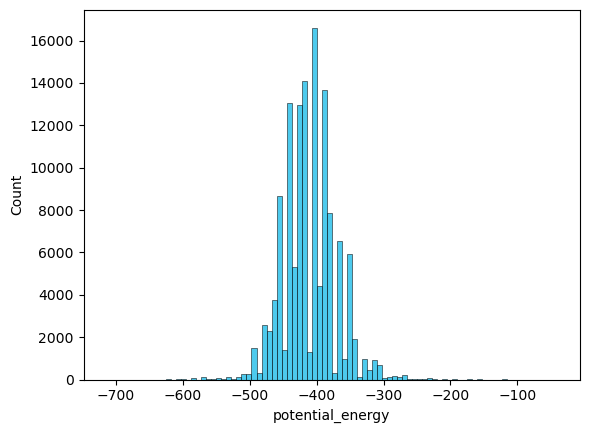

In [34]:
# Distribution of potential energy with histogram

sns.histplot(data["potential_energy"],kde= False ,bins = 90 ,  color = "#11B9E8")
# here i do need to adjust bins manually for better results , at fd results are tremendous

In [35]:
data["potential_energy"].describe()

count    130789.000000
mean       -410.951413
std          39.839916
min        -714.626197
25%        -438.002671
50%        -416.920943
75%        -387.221827
max         -40.523680
Name: potential_energy, dtype: float64

### Distribution of Potential Energy

The potential energy values range from -714.63 to -40.52, with a mean of -410.95 and a standard deviation of 39.84. Most molecules lie between -438.00 and -387.22. The histogram exhibits multiple peaks and slight tailing, indicating a non-normal distribution and suggesting the presence of distinct molecular populations within the dataset.

<Axes: xlabel='dipole_moment', ylabel='Count'>

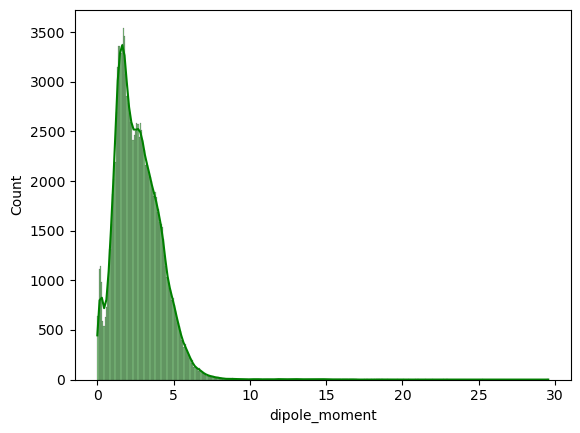

In [36]:
#Distribution plot of dipole moment
sns.histplot(data["dipole_moment"] , kde = True ,  color = "green")

In [37]:
data["dipole_moment"].describe()

count    130789.000000
mean          2.673467
std           1.503359
min           0.000000
25%           1.578233
50%           2.475726
75%           3.596739
max          29.556384
Name: dipole_moment, dtype: float64

### Distribution of Dipole Moment Magnitudes

Dipole moment magnitudes are centered around 2.67 with a standard deviation of 1.50. Most molecules possess dipole moments below 5, and the distribution exhibits positive skewness with a long right tail, indicating the presence of a small number of highly polar molecules.

<Axes: >

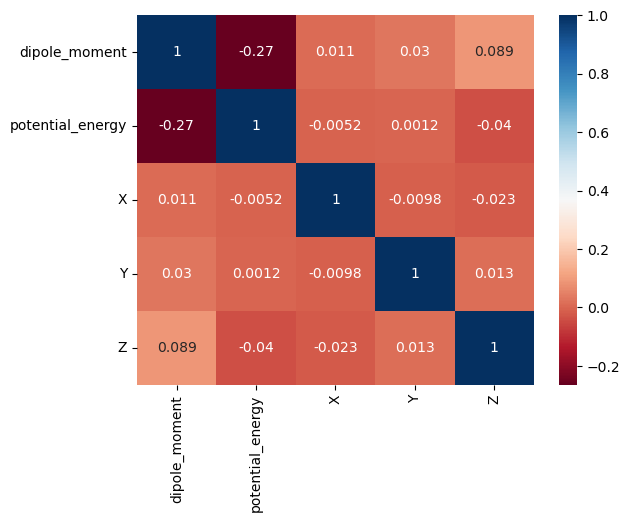

In [38]:
# Correlation of Variables
sns.heatmap(data[["dipole_moment","potential_energy","X",'Y','Z']].corr(),
            annot= True ,
            cmap = "RdBu"
            )

### Correlation of Variables

The correlation matrix indicates a weak negative correlation (-0.27) between dipole moment magnitude and potential energy. The individual Cartesian components (X, Y, and Z) exhibit negligible correlations with potential energy, with coefficients close to zero.

Overall, the absence of strong linear relationships suggests that molecular potential energy is not directly determined by dipole moment components alone, motivating the use of machine learning models to investigate potential nonlinear dependencies.

<Axes: xlabel='dipole_moment', ylabel='potential_energy'>

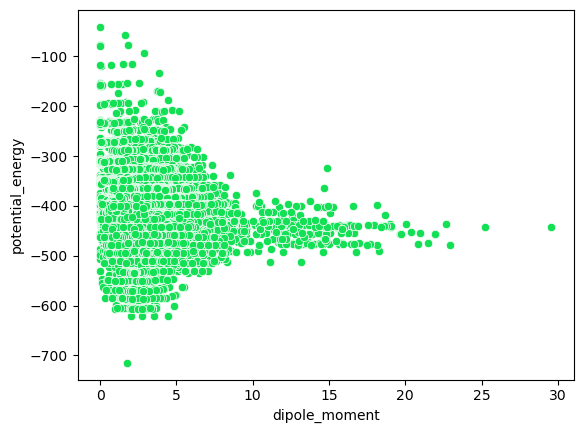

In [39]:
# scatterplot btwn Dipole moment and potential energy
sns.scatterplot(data= data, x = "dipole_moment" , y = "potential_energy" , color = "#14E055FF")

### Relationship Between Dipole Moment and Potential Energy

The scatter plot reveals a weak negative association between dipole moment magnitude and potential energy. Molecules with low dipole moments exhibit a broad range of energy values, whereas higher dipole moments are associated with a narrower energy range.

No clear linear trend is observed, and substantial variability exists across the entire range of dipole moments. This suggests that dipole moment alone may not sufficiently explain molecular potential energy and that additional molecular descriptors are likely required.

---
# Splitting data

In [41]:
X = data[["X","Y","Z","dipole_moment"]] # feature we will be considering
Y = data["potential_energy"] #Target

x_train, x_test, y_train, y_test = skl.model_selection.train_test_split(X , Y , test_size = 0.2 , random_state = 42 )

In [43]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test :", x_test.shape)
print("y_test :", y_test.shape)

x_train: (104631, 4)
y_train: (104631,)
x_test : (26158, 4)
y_test : (26158,)


The dataset was randomly split into training (80%) and testing (20%) sets using a fixed random seed (`random_state = 42`) to ensure reproducibility.

---
# Lets Now use model on this for further predictions
## 1. Linear Regression

In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.05, 0.18,-0.59,-6.93]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['X','Y','Z','dipole_moment']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-392.3
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


In [44]:
pred = model.predict(x_test)

# Linear Regression

Linear Regression is a supervised machine learning algorithm used to model the relationship between one or more input variables and a continuous target variable.

In this study, the model attempts to learn a relationship between molecular dipole moment features (`X`, `Y`, `Z`, and dipole magnitude`) and molecular potential energy.

The model assumes a linear relationship of the form:

$$
\hat{y} = \beta_0 + \beta_1X + \beta_2Y + \beta_3Z + \beta_4\mu
$$

where:

- $\hat{y}$ is the predicted potential energy,
- $\beta_0$ is the intercept,
- $\beta_1, \beta_2, \beta_3,$ and $\beta_4$ are learned coefficients,
- $\mu$ is the dipole moment magnitude.

During training, the algorithm determines the coefficients that minimize the difference between the predicted and actual potential energy values. This is achieved by minimizing the Mean Squared Error (MSE):

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Linear Regression serves as a baseline model for this study. Its performance provides an initial indication of whether molecular dipole moments contain useful information for predicting molecular potential energy.

Text(0.5, 0, 'Actual')

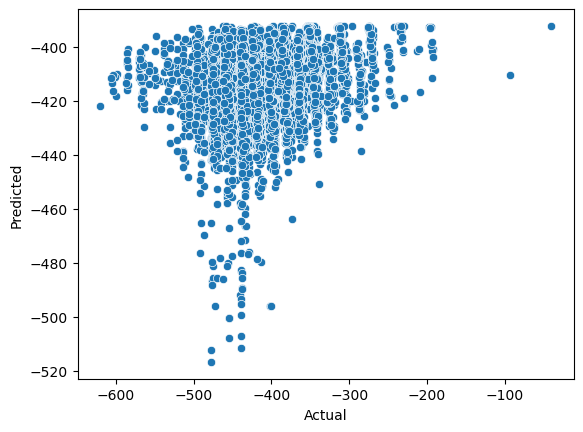

In [49]:
#lest have a look how our data actually worked lets see relations in y_test and pred
sns.scatterplot(x = y_test , y = pred)
plt.ylabel("Predicted")
plt.xlabel("Actual")

In [54]:
model.score(x_train,y_train) * 100

6.9462730910512915

In [53]:
model.score(x_test,y_test) * 100

7.576403854463754

### Linear Regression Performance

The Linear Regression model achieved an R² score of approximately 0.07, indicating that the dipole moment features explain only about 7% of the variation in molecular potential energy. Although a weak relationship exists between dipole moments and potential energy, the low explanatory power suggests that dipole moments alone are insufficient for accurate prediction.